#Hotel-A Train

## Phase 1: Pre-Cleaning EDA (Data Profiling)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Data Loading

In [ ]:
#loading dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DPLC/CW/raw/Hotel-A-validation.csv')

### Basic Overview

In [ ]:
df.shape

(2749, 24)

In [ ]:
#exploring datatypes of each variable, number of fields and rows
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2749 entries, 0 to 2748
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Reservation-id          2749 non-null   int64 
 1   Gender                  2749 non-null   object
 2   Age                     2749 non-null   int64 
 3   Ethnicity               2749 non-null   object
 4   Educational_Level       2749 non-null   object
 5   Income                  2749 non-null   object
 6   Country_region          2749 non-null   object
 7   Hotel_Type              2749 non-null   object
 8   Expected_checkin        2749 non-null   object
 9   Expected_checkout       2749 non-null   object
 10  Booking_date            2749 non-null   object
 11  Adults                  2749 non-null   int64 
 12  Children                2749 non-null   int64 
 13  Babies                  2749 non-null   int64 
 14  Meal_Type               2749 non-null   object
 15  Vist

Date/time data (expected_checkin, expected_checkout, booking_date) has been stored in object form, which will cause issues because the data will be treated as text.
Therefore, it will not show trends or help identify seasonality.  

In [ ]:
#checking for null values
df.isnull().sum()

,0
Reservation-id,0
Gender,0
Age,0
Ethnicity,0
Educational_Level,0
Income,0
Country_region,0
Hotel_Type,0
Expected_checkin,0
Expected_checkout,0


In [ ]:
#checking for duplicates for reservation id only as it is assumed to be a unique value
duplicate_count = df.duplicated(subset=['Reservation-id']).sum()
duplicate_count

np.int64(0)

### Summary Statistics

In [ ]:
#descriptive statistics of numerical variables
df.describe()

,Reservation-id,Age,Adults,Children,Babies,Discount_Rate,Room_Rate
count,2.749000e+03,2749.000000,2749.000000,2749.000000,2749.000000,2749.000000,2749.000000
mean,4.991827e+07,44.196799,2.336850,1.740633,0.333940,12.484540,173.742452
std,2.888011e+07,15.212212,1.185808,0.724913,0.566997,11.166182,43.880178
min,1.430000e+02,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000
25%,2.484313e+07,31.000000,1.000000,1.000000,0.000000,5.000000,136.000000
50%,4.932876e+07,44.000000,2.000000,2.000000,0.000000,10.000000,173.000000
75%,7.471297e+07,57.000000,3.000000,2.000000,1.000000,20.000000,212.000000
max,9.998849e+07,70.000000,5.000000,3.000000,2.000000,40.000000,250.000000



*   **Age:** The average age of guests is around 44 years,The minimum age is 18 and the maximum is 70, which aligns with typical adult age groups for hotel bookings.
*   **Adults:** On average, there are about 2.3 adults per reservation. The range is from 1 to 5 adults.
*   **Children:** There are typically around 1.7 children per reservation, ranging from 1 to 3.
*   **Babies:** The average number of babies is low, about 0.33 per reservation, with a maximum of 2, suggesting that bookings with babies are less frequent.
*   **Room_Rate:** The average room rate is around 173.74, with a standard deviation of about 43.88. Rates range from 100 to 250.



In [ ]:
#descriptive statistics of catergorical variables
df.describe(include=['object'])

,Gender,Ethnicity,Educational_Level,Income,Country_region,Hotel_Type,Expected_checkin,Expected_checkout,Booking_date,Meal_Type,Visted_Previously,Previous_Cancellations,Deposit_type,Booking_channel,Required_Car_Parking,Reservation_Status,Use_Promotion
count,2749,2749,2749,2749,2749,2749,2749,2749,2749,2749,2749,2749,2749,2749,2749,2749,2749
unique,2,4,4,4,4,3,151,156,322,3,2,2,3,3,2,3,2
top,F,caucasian,College,50K -- 100K,South,Airport Hotels,10/6/2016,10/13/2016,6/1/2016,FB,No,No,No Deposit,Online,Yes,Check-In,Yes
freq,1396,697,1124,786,1093,976,86,67,23,937,1791,2421,1843,1569,1959,1610,2085



*   **Gender:** The dataset is almost equally split between Female (F) and Male (M) guests.

*   **Hotel_Type:** 'Airport Hotels' are the most frequently booked type, followed by 'City Hotel' and 'Resort'.

*   **Meal_Type:** 'FB' (Full Board) is the most popular meal type, followed closely by 'BB' (Bed and Breakfast) and 'HB' (Half Board).\

*   **Visted_Previously:** A majority of guests have not visited previously, suggesting a good portion of new customers.

*   **Previous_Cancellations:** Most reservations do not have previous cancellations, which is a positive indicator.

*   **Deposit_type:** 'No Deposit' is the most common, followed by 'Refundable' and 'Non-Refundable'. This is a critical insight, as 'No Deposit' policies can influence cancellation rates.

*   **Booking_channel:** 'Online' is the dominant booking channel, followed by 'Direct' and 'Agent'.

*   **Required_Car_Parking:** A significant majority of guests ('Yes') require car parking.

*   **Use_Promotion:** Most reservations utilize promotions.


### Categorical variables check

In [ ]:
# checking for casing inconsistencies in categorical variables
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    print(df[col].value_counts())
    print("\n")

Gender
F    1396
M    1353
Name: count, dtype: int64


Ethnicity
caucasian           697
Latino              685
African American    685
Asian American      682
Name: count, dtype: int64


Educational_Level
College        1124
Mid-School      553
Grad            540
High-School     532
Name: count, dtype: int64


Income
50K -- 100K    786
<25K           785
25K --50K      778
>100K          400
Name: count, dtype: int64


Country_region
South    1093
East      563
North     560
West      533
Name: count, dtype: int64


Hotel_Type
Airport Hotels    976
City Hotel        901
Resort            872
Name: count, dtype: int64


Expected_checkin
10/6/2016     86
10/20/2016    71
10/11/2016    69
10/12/2016    65
11/12/2016    62
              ..
1/21/2017      1
3/5/2017       1
6/14/2017      1
2/10/2017      1
11/21/2016     1
Name: count, Length: 151, dtype: int64


Expected_checkout
10/13/2016    67
10/7/2016     66
10/12/2016    55
10/31/2016    53
10/21/2016    50
              ..
12/12

### Univariate Analysis

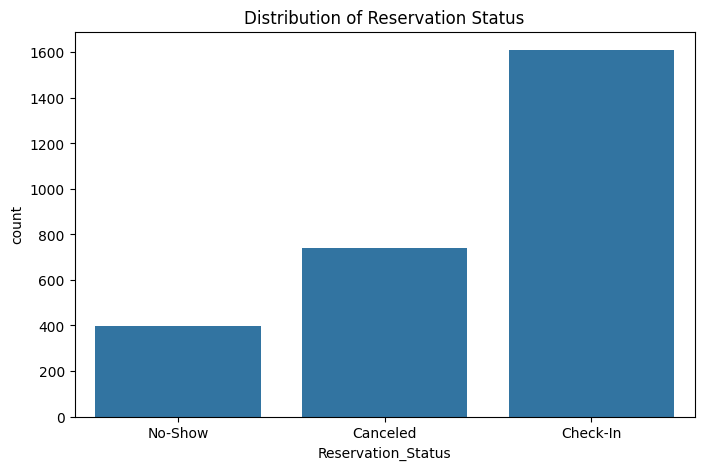

In [ ]:
#Visualising to check for incosistenies in reservation status
plt.figure(figsize=(8, 5))
sns.countplot(x='Reservation_Status', data=df)
plt.title('Distribution of Reservation Status')
plt.show()


This plot shows the overall distribution of reservation statuses. A significant portion of reservations result in 'Check-In', followed by 'Canceled' and then 'No-Show'. This indicates that while most bookings proceed as planned, cancellations and no-shows are also notable events that could impact hotel occupancy and revenue.

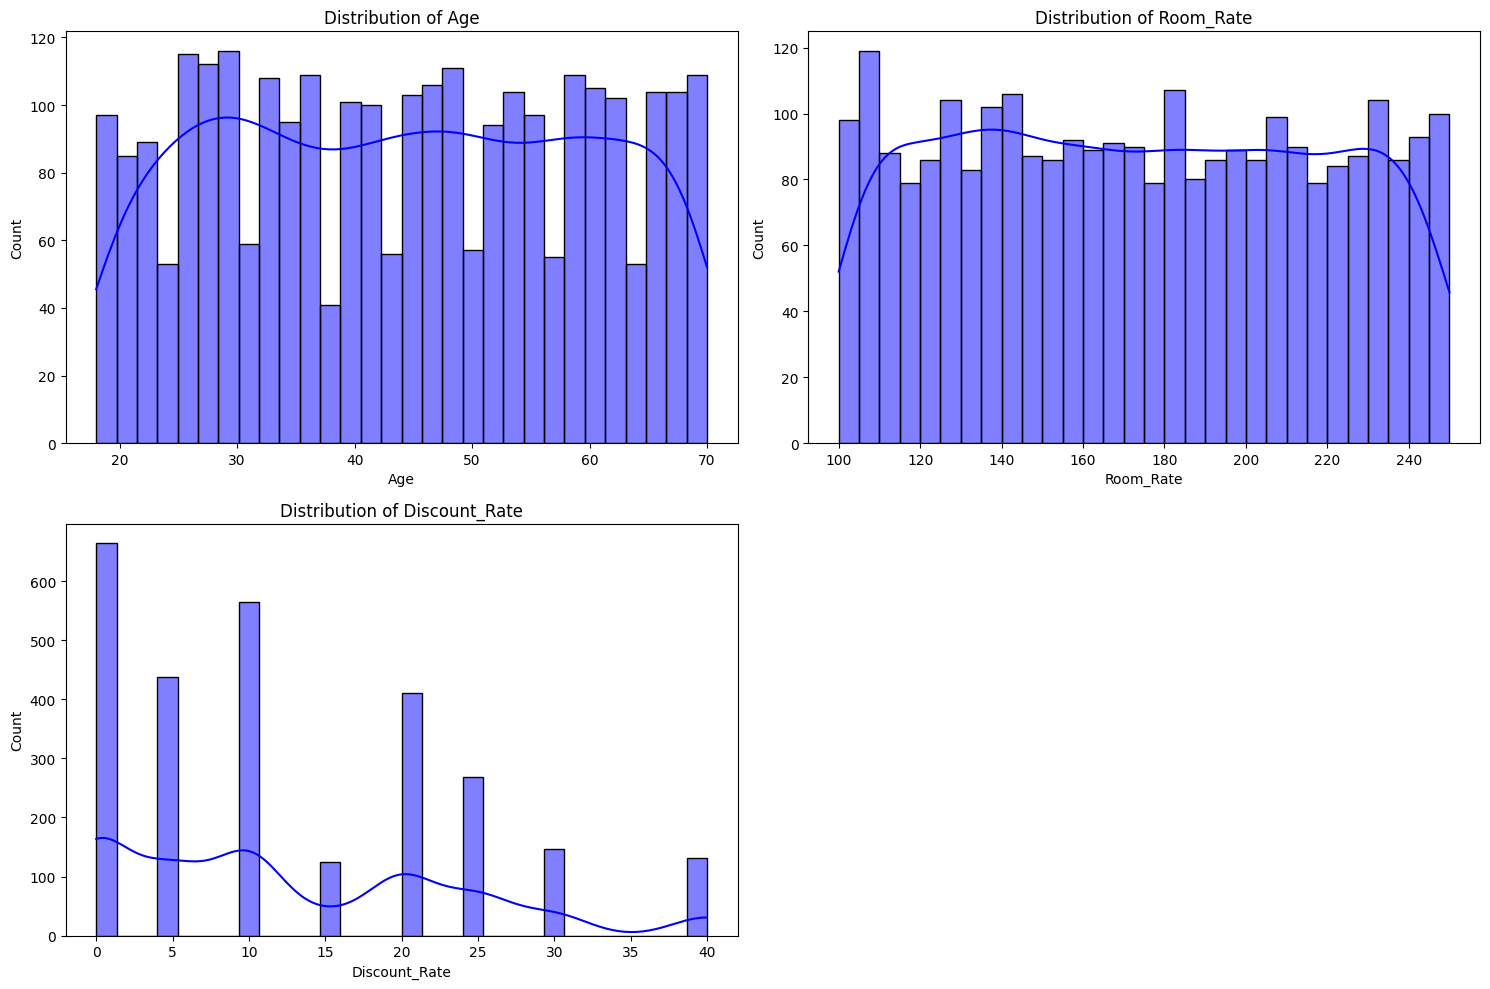

In [ ]:
#Numerical Variables: Histograms
num_vars = ['Age','Room_Rate', 'Discount_Rate']
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_vars, 1):
    if col in df.columns:
        plt.subplot(2, 2, i)
        sns.histplot(df[col], bins=30, kde=True, color='blue')
        plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()


- **Age:** The age distribution appears to be relatively uniform across the range of 18 to 70, with slight peaks around mid-range ages. This suggests a diverse age demographic among the hotel guests.
- **Room_Rate:** Room rates show a normal distribution centered around the average, indicating a mix of affordable and higher-priced rooms being booked.
- **Discount_Rate:** The discount rates are varied.Many bookings seem to have no discount (0%), while others benefit from various discount percentages.

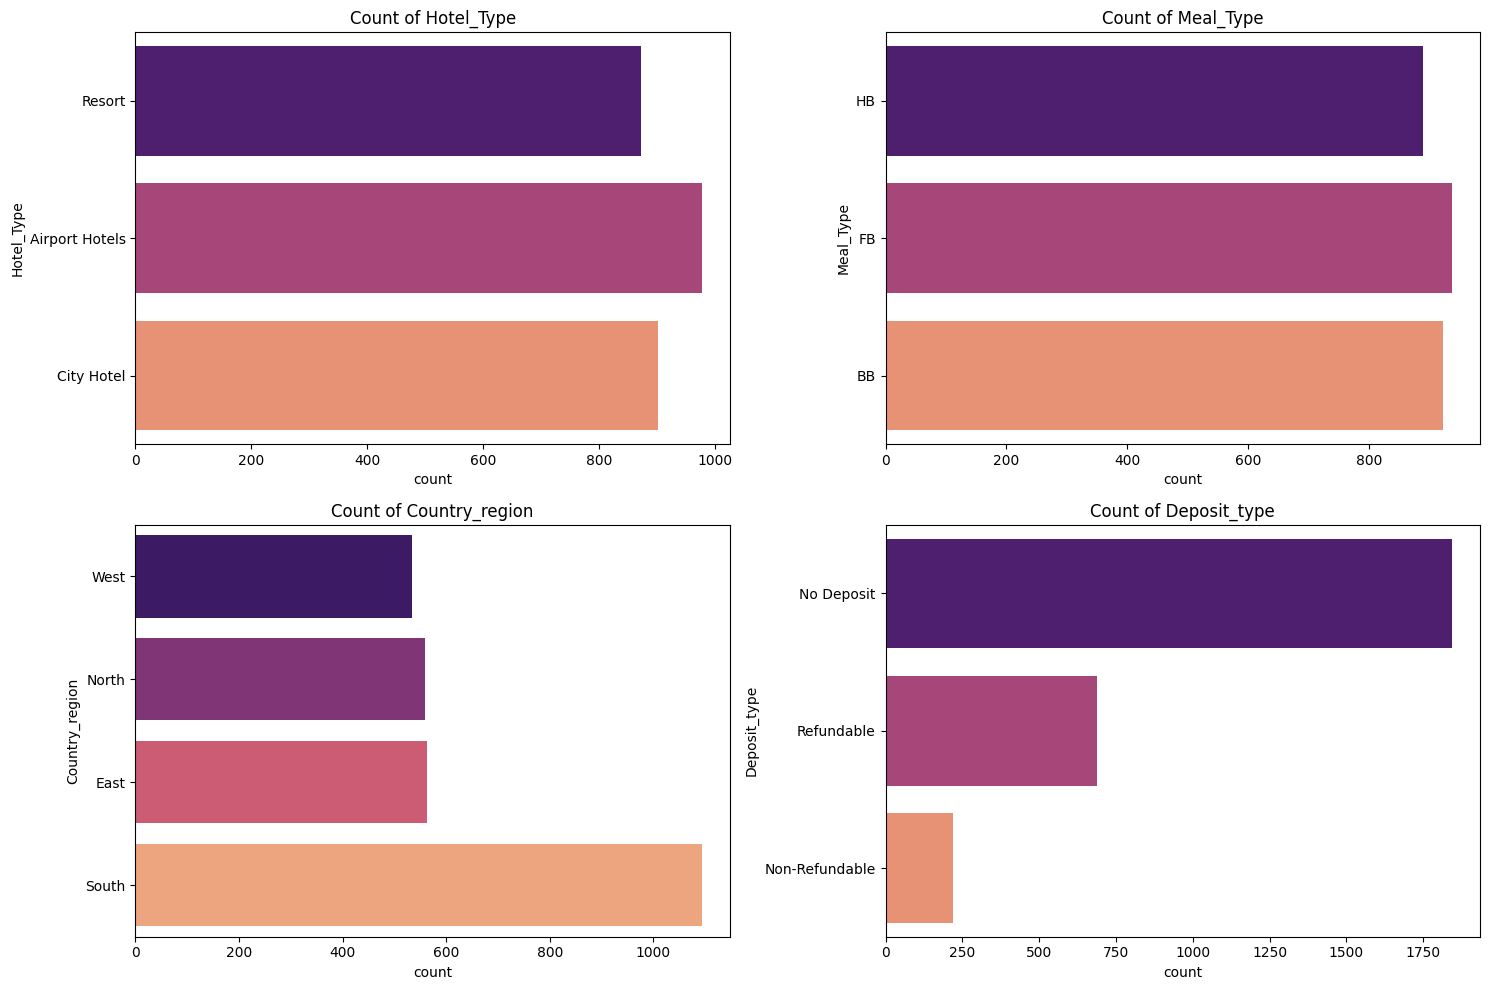

In [ ]:
#Categorical Variables: Bar Charts
cat_vars = ['Hotel_Type', 'Meal_Type', 'Country_region', 'Deposit_type']
plt.figure(figsize=(15, 10))
for i, col in enumerate(cat_vars, 1):
    if col in df.columns:
        plt.subplot(2, 2, i)
        sns.countplot(y=col, data=df, hue=col, legend=False, palette='magma')
        plt.title(f'Count of {col}')
plt.tight_layout()
plt.show()


- **Hotel_Type:** 'Airport Hotels' are the most frequently booked, followed by 'City Hotel' and 'Resort', indicating a preference or higher availability for airport-located accommodations.
- **Meal_Type:** 'FB' (Full Board) and 'BB' (Bed and Breakfast) are the most popular meal types, with 'HB' (Half Board) being slightly less common.
- **Country_region:** The 'South' region accounts for the highest number of bookings, suggesting a strong customer base or marketing focus in that area.
- **Deposit_type:** 'No Deposit' is the most common deposit type, which could attract more bookings but also potentially lead to higher cancellation rates compared to refundable or non-refundable options.

### Bivariate Analysis

<Figure size 1000x600 with 0 Axes>

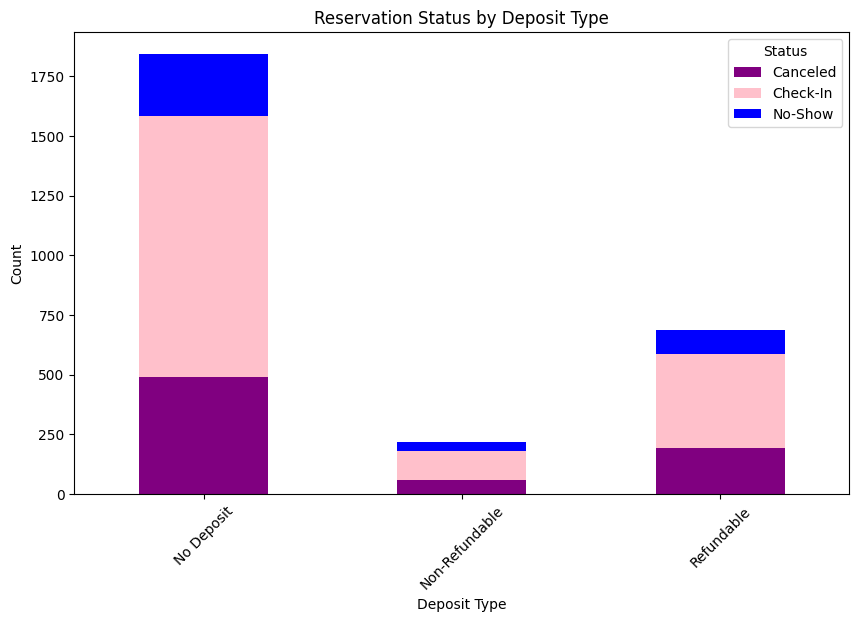

In [ ]:
#Status vs Deposit Type
plt.figure(figsize=(10, 6))
deposit_status = pd.crosstab(df['Deposit_type'], df['Reservation_Status'])
deposit_status.plot(kind='bar', stacked=True, figsize=(10, 6), color=['purple', 'pink', 'blue'])
plt.title('Reservation Status by Deposit Type')
plt.xlabel('Deposit Type')
plt.ylabel('Count')
plt.legend(title='Status')
plt.xticks(rotation=45)
plt.show()


This stacked bar chart clearly shows that 'No Deposit' reservations have the highest proportion of 'Canceled' and 'No-Show' statuses. 'Non-Refundable' deposits, have a very low rate of cancellations and no-shows, primarily resulting in 'Check-In'. 'Refundable' deposits also show a good proportion of check-ins but have more cancellations and no-shows than non-refundable deposits, likely due to the flexibility they offer.

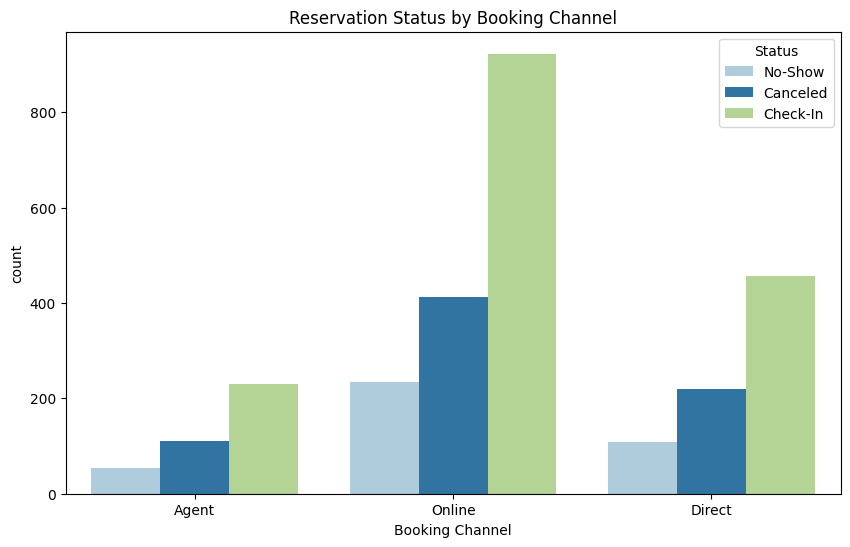

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Booking_channel', hue='Reservation_Status', data=df, palette='Paired')
plt.title('Reservation Status by Booking Channel')
plt.xlabel('Booking Channel')
plt.legend(title='Status')
plt.show()


'Online' booking is the most frequent channel, followed by 'Direct' and 'Agent'. Online bookings contribute significantly to 'Check-In', but also to 'Canceled' and 'No-Show' statuses. Direct bookings show a higher proportion of 'Check-In' relative to cancellations/no-shows, while 'Agent' bookings also have a healthy 'Check-In' rate, but with some cancellations.

### Multivariate Analysis

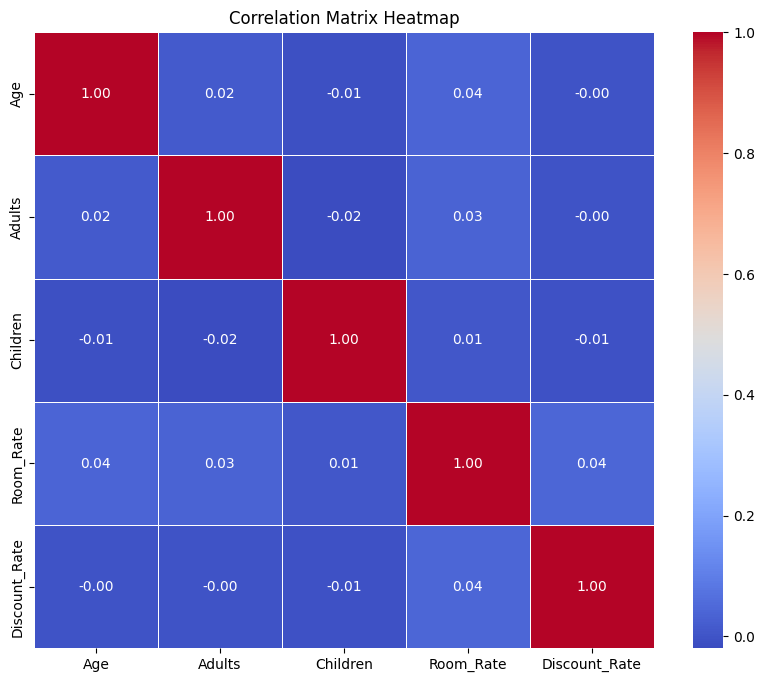

In [ ]:
corr_cols = ['Age', 'Adults', 'Children', 'Room_Rate', 'Discount_Rate']
corr_data = df[corr_cols]
corr_matrix = corr_data.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()


This heatmap displays the correlation between selected numerical variables. Key observations:
- 'Adults' and 'Children' show a moderate positive correlation, suggesting that bookings with more adults often include children.
- 'Room_Rate' and 'Discount_Rate' have a weak negative correlation, meaning higher room rates are not strongly associated with higher discounts.
- 'Age' shows very weak correlations with other variables, implying that a guest's age doesn't significantly influence the number of adults/children, room rate, or discount rate in a linear form.

### Outlier Check

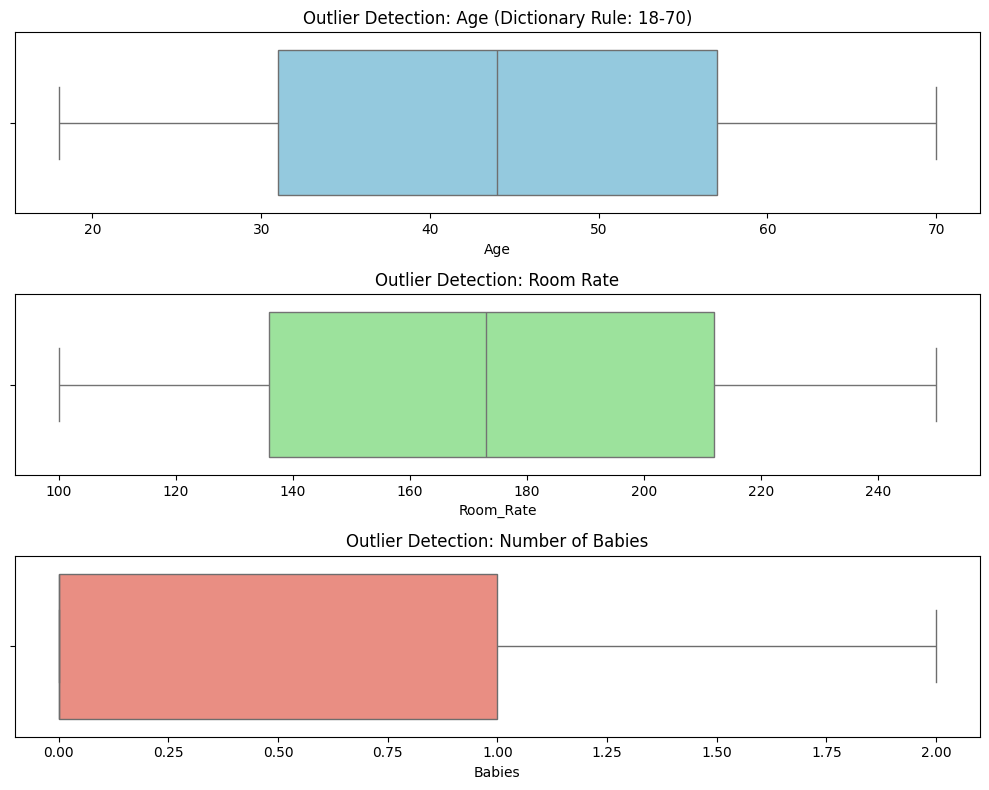

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8))

# 1. Check Age
sns.boxplot(x=df['Age'], ax=axes[0], color='skyblue')
axes[0].set_title('Outlier Detection: Age (Dictionary Rule: 18-70)')

# 2. Check Room Rate
sns.boxplot(x=df['Room_Rate'], ax=axes[1], color='lightgreen')
axes[1].set_title('Outlier Detection: Room Rate')

# 3. Check Babies
sns.boxplot(x=df['Babies'], ax=axes[2], color='salmon')
axes[2].set_title('Outlier Detection: Number of Babies')

plt.tight_layout()
plt.show()

 **Age:** The box plot for 'Age' shows no visible outliers, consistent with the dictionary rule that ages are between 18 and 70.

 **Room_Rate:** The 'Room_Rate' box plot indicates a normal distribution with no apparent outliers, suggesting consistent pricing within the dataset.

**Babies:** The 'Babies' box plot shows that most reservations have 0 babies, with some having 1 or 2.

### Business Rule Validation (Data Dictionary Checks)

In [ ]:
#Calculating total number of guests (Adults + Children only) to find rows where Adults + Children > 5
overcapacity_filter = (df['Adults'] + df['Children']) > 5
df.loc[overcapacity_filter, ['Reservation-id', 'Adults', 'Children']]

,Reservation-id,Adults,Children
8,95113258,3,3
9,24700715,4,2
15,16849965,5,1
31,22945481,5,1
32,63793439,5,2
...,...,...,...
2711,93436693,4,3
2721,73486584,4,2
2730,18344155,4,2
2744,32194836,5,1


In [ ]:
#check for invalid ages (less than 18 OR greater than 70)
age_filter = (df['Age'] < 18) | (df['Age'] > 70)
df.loc[age_filter, ['Reservation-id', 'Age']]

,Reservation-id,Age


## Phase 2: Data Cleaning

In [ ]:
# 1. convert categorical col into upper case
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    # .upper() converts "city hotel" to "CITY HOTEL"
    # .strip() removes accidental leading/trailing spaces
    df[col] = df[col].astype(str).str.strip().str.lower()

In [ ]:
  df['Meal_Type'] = df['Meal_Type'].str.lower() # Keep BB, HB, FB as uppercase

In [ ]:
df['Reservation_Status'].unique()

array(['no-show', 'canceled', 'check-in'], dtype=object)

In [ ]:
# Unifying the 'Success' labels (after converting to uppercase in a previous step)
df['Reservation_Status'] = df['Reservation_Status'].replace('check-in', 'check-out')

In [ ]:
df['Reservation_Status'].isnull().sum()

np.int64(0)

In [ ]:
# 3. handle date conversions
date_columns = ['Expected_checkin', 'Expected_checkout', 'Booking_date']

for col in date_columns:
    # errors='coerce' turns completely broken dates into NaT (Not a Time)
    df[col] = pd.to_datetime(df[col], errors='coerce')

In [ ]:
# 4. Handling Duplicates
df = df.drop_duplicates(subset=['Reservation-id'], keep='first')
print(f"Remaining duplicate IDs: {df.duplicated(subset=['Reservation-id']).sum()}")

Remaining duplicate IDs: 0


## Feature Engineering

In [ ]:
df['Lead_Time'] = (df['Expected_checkin'] - df['Booking_date']).dt.days

In [ ]:
df['Length_of_Stay'] = (df['Expected_checkout'] - df['Expected_checkin']).dt.days

In [ ]:
df['Total_Guests'] = df['Adults'] + df['Children']
df.drop(['Adults', 'Children', 'Babies'], axis=1, inplace=True)

In [ ]:
df['Checkin_Month'] = df['Expected_checkin'].dt.month

In [ ]:
df['Is_Weekend'] = df['Expected_checkin'].dt.weekday.isin([5, 6]).astype(int)

In [ ]:
# Drop rows where Booking Date is after Check-in (invalid data)
df = df[df['Lead_Time'] >= 0].copy()

## Encoding

In [ ]:
# 1. Encode Target (Reservation_Status)
# Mapping: CHECK-IN: 1, CANCELED: 2, NO-SHOW: 3 (keys adjusted to match uppercase values)
target_mapping = {'check-out': 1, 'canceled': 2, 'no-show': 3}
df['Reservation_Status'] = df['Reservation_Status'].map(target_mapping)

In [ ]:
# 2. Encode Categorical Features
# Identify columns that are objects

categorical_features = df.select_dtypes(include=['object']).columns.tolist()
if 'Reservation-id' in categorical_features: categorical_features.remove('Reservation-id')

validation_final = pd.get_dummies(df, columns=categorical_features, drop_first=True)

In [ ]:
validation_final.head()

,Reservation-id,Age,Expected_checkin,Expected_checkout,Booking_date,Reservation_Status,Discount_Rate,Room_Rate,Lead_Time,Length_of_Stay,...,Meal_Type_fb,Meal_Type_hb,Visted_Previously_yes,Previous_Cancellations_yes,Deposit_type_non-refundable,Deposit_type_refundable,Booking_channel_direct,Booking_channel_online,Required_Car_Parking_yes,Use_Promotion_yes
0,45716350,56,2016-08-31,2016-09-02,2016-02-18,3,15,192,195,2,...,False,True,False,False,False,False,False,False,False,True
1,88857401,60,2016-08-31,2016-09-04,2016-03-09,2,0,187,175,4,...,True,False,True,False,False,False,False,True,True,False
2,16074440,58,2016-09-01,2016-09-02,2016-02-21,2,10,227,193,1,...,True,False,False,False,False,False,True,False,False,True
3,10992124,23,2016-08-31,2016-09-02,2016-05-20,1,25,189,103,2,...,True,False,True,False,False,True,True,False,False,True
4,15934351,47,2016-08-31,2016-09-01,2016-05-31,1,10,218,92,1,...,False,True,True,False,False,False,False,True,True,True


In [ ]:
validation_final.head()

,Reservation-id,Age,Expected_checkin,Expected_checkout,Booking_date,Reservation_Status,Discount_Rate,Room_Rate,Lead_Time,Length_of_Stay,...,Meal_Type_fb,Meal_Type_hb,Visted_Previously_yes,Previous_Cancellations_yes,Deposit_type_non-refundable,Deposit_type_refundable,Booking_channel_direct,Booking_channel_online,Required_Car_Parking_yes,Use_Promotion_yes
0,45716350,56,2016-08-31,2016-09-02,2016-02-18,3,15,192,195,2,...,False,True,False,False,False,False,False,False,False,True
1,88857401,60,2016-08-31,2016-09-04,2016-03-09,2,0,187,175,4,...,True,False,True,False,False,False,False,True,True,False
2,16074440,58,2016-09-01,2016-09-02,2016-02-21,2,10,227,193,1,...,True,False,False,False,False,False,True,False,False,True
3,10992124,23,2016-08-31,2016-09-02,2016-05-20,1,25,189,103,2,...,True,False,True,False,False,True,True,False,False,True
4,15934351,47,2016-08-31,2016-09-01,2016-05-31,1,10,218,92,1,...,False,True,True,False,False,False,False,True,True,True


In [ ]:
import numpy as np

# Create Lead Time Categories
# 0-7 days: Last Minute (Low Cancel)
# 7-30 days: Short Term
# 30-90 days: Medium Term
# 90+ days: Long Term (High Cancel Risk)
df['Lead_Time_Category'] = pd.cut(df['Lead_Time'],
                                  bins=[-np.inf, 7, 30, 90, np.inf],
                                  labels=['Last_Minute', 'Short_Term', 'Medium_Term', 'Long_Term'])

In [ ]:
validation_final.to_csv('Hotel_A_Validation_Cleaned.csv', index=False)

In [ ]:

print(validation_final.shape[1])

38


In [ ]:
from google.colab import files

# This will trigger a browser download for the file
files.download('Hotel_A_Validation_Cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(f"Original Columns: {len(df.columns)}")
print(f"Post-Encoding Columns: {len(validation_final.columns)}")

# See which categories created the most columns
new_cols = [c for c in validation_final.columns if c not in df.columns]
print(f"\nCreated {len(new_cols)} new binary columns.")

Original Columns: 27
Post-Encoding Columns: 38

Created 25 new binary columns.
